<a href="https://colab.research.google.com/github/sunil965/masai-aiml/blob/master/M4C3%20IITR_Decision_Tree_for_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Agenda: Decision Trees for Classification

In [ ]:
#Decision Tree
# 1. Root
# 2. Internal Node
# 3. Branch
# 4. Leaf Node




In [ ]:
import pandas as pd

data = {
    "StudyHours": [
        1, 2, 2, 3, 3,
        4, 4, 5, 5, 6,
        6, 7, 7, 8, 9
    ],

    "Attendance": [
        50, 55, 60, 65, 68,
        70, 72, 75, 78, 80,
        82, 85, 88, 92, 95
    ],

    "Assignments": [
        2, 3, 3, 4, 4,
        5, 5, 6, 7, 7,
        8, 8, 9, 9, 10
    ],

    "Passed": [
        0, 0, 0, 0, 0,
        0, 0, 1, 1, 1,
        1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)

df

,StudyHours,Attendance,Assignments,Passed
0,1,50,2,0
1,2,55,3,0
2,2,60,3,0
3,3,65,4,0
4,3,68,4,0
5,4,70,5,0
6,4,72,5,0
7,5,75,6,1
8,5,78,7,1
9,6,80,7,1


In [ ]:
#0 -> fail, 1 -> pass

In [ ]:
x = df.drop("Passed", axis = 1)
y = df["Passed"]


In [ ]:
x

,StudyHours,Attendance,Assignments
0,1,50,2
1,2,55,3
2,2,60,3
3,3,65,4
4,3,68,4
5,4,70,5
6,4,72,5
7,5,75,6
8,5,78,7
9,6,80,7


In [ ]:
y

,Passed
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,1
8,1
9,1


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state = 40)


In [ ]:
x_train.head()

,StudyHours,Attendance,Assignments
14,9,95,10
3,3,65,4
9,6,80,7
4,3,68,4
1,2,55,3


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)


In [ ]:
model.fit(x_train, y_train)


DecisionTreeClassifier(random_state=42)

In [ ]:
predictions = model.predict(x_test)
print(predictions)

[0 1 1]


In [ ]:
print(y_test)

0     0
12    1
13    1
Name: Passed, dtype: int64


In [ ]:
#  Attendance <= 73?
#     /       \
#   Yes        No
#   /           \
# Fail      StudyHours <= 4?
#              /       \
#            Yes        No
#            /           \
#          Fail         Assignments <= 4

                        #     / \
                        #   Yes  No
                        #   /      \
                        # Fail      Pass

In [ ]:
#Visualize the Decision Tree

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt



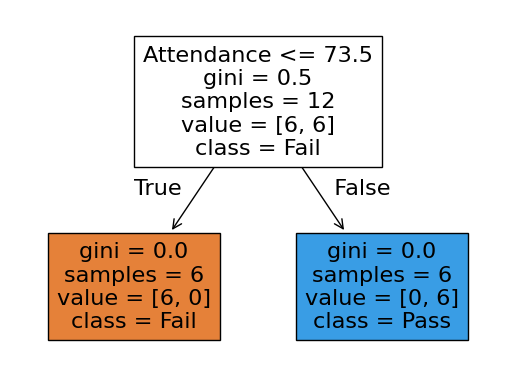

In [ ]:
plot_tree(
    model,
    feature_names= x.columns,
    class_names = ["Fail", "Pass"],
    filled = True
)

plt.show()

In [ ]:
model2 = DecisionTreeClassifier(criterion="entropy", random_state=42)

model2.fit(x_train, y_train)

predictions = model2.predict(x_test)
print(predictions)

[0 1 1]


In [ ]:
model3 = DecisionTreeClassifier(
    max_depth = 3,
    random_state = 42
)

model3.fit(x_train, y_train)
model3.predict(x_test)

array([0, 1, 1])

In [ ]:
model3.score(x_test, y_test)

1.0

In [ ]:
print(y_test)

0     0
12    1
13    1
Name: Passed, dtype: int64


In [ ]:
depths = [2,3,4,5,7,10]

# train model, test_accuracy, train_accuracy

In [ ]:
depths = [2,3,4,5,7,10]

for d in depths:

  model = DecisionTreeClassifier(
      max_depth = d,
      random_state = 42
  )

  model.fit(x_train, y_train)

  train_accuracy = model.score(x_train, y_train)

  test_accuracy = model.score(x_test, y_test)

  print("train_accuracy", train_accuracy)
  print("test_accuracy", test_accuracy)


train_accuracy 1.0
test_accuracy 1.0
train_accuracy 1.0
test_accuracy 1.0
train_accuracy 1.0
test_accuracy 1.0
train_accuracy 1.0
test_accuracy 1.0
train_accuracy 1.0
test_accuracy 1.0
train_accuracy 1.0
test_accuracy 1.0


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(x_train, y_train)
predictions = model.predict(x_test)
print(predictions)

[0 1 1]


In [ ]:
o o o
    o o o o

----------------------

x x x x x
      x x x